### Machine Learning Analysis

This notebook applies multiple machine learning models to predict divorce status using demographic variables.  
The dataset was sampled to improve computational efficiency.

In [51]:
import pandas as pd

df = pd.read_csv("data/usa_00001.csv")

df['divorced'] = (df['MARST'] == 4).astype(int)

df_sample = df.sample(n=100000, random_state=42)

print(df.shape)
print(df_sample.shape)
df_sample.head()

(3405809, 21)
(100000, 21)


,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEICP,STRATA,GQ,PERNUM,...,SEX,AGE,MARST,EDUC,EDUCD,EMPSTAT,EMPSTATD,INCWAGE,POVERTY,divorced
2744464,2023,202301,1233692,2023000236556,62.0,2023012336921,54,210147,1,2,...,2,31,1,11,114,3,30,0,428,0
875515,2023,202301,382725,2023001353383,23.0,2023003827251,43,310112,1,3,...,1,5,6,1,12,0,0,999999,186,0
824648,2023,202301,360770,2023000988765,42.0,2023003607701,43,861812,1,1,...,2,41,1,7,71,1,10,100000,501,0
2806864,2023,202301,1262562,2023010051424,6.0,2023012625621,49,591148,4,1,...,1,18,6,6,63,3,30,0,0,0
1039079,2023,202301,454567,2023010080322,136.0,2023004545671,21,490017,3,1,...,2,64,6,8,81,3,30,0,0,0


In [52]:
df = pd.read_csv("data/usa_00001.csv")

df['divorced'] = (df['MARST'] == 4).astype(int)

df[['MARST', 'divorced']].head()

df['divorced'].value_counts()

divorced
0    3100501
1     305308
Name: count, dtype: int64

In [53]:
features = ['AGE', 'SEX', 'EDUC', 'EMPSTAT']
X = df_sample[features]
y = df_sample['divorced']

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(80000, 4) (20000, 4)


In [55]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.91205
Precision: 0.0
Recall: 0.0
Confusion Matrix:
 [[18241     0]
 [ 1759     0]]


/opt/anaconda3/envs/dsa_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [57]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6091
Precision: 0.14940400416618446
Recall: 0.7339397384877772
Confusion Matrix:
 [[10891  7350]
 [  468  1291]]


In [59]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Precision:", precision_score(y_test, y_pred_knn))
print("KNN Recall:", recall_score(y_test, y_pred_knn))

KNN Accuracy: 0.9001
KNN Precision: 0.13230769230769232
KNN Recall: 0.0244457077885162


In [60]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced')
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))
print("DT Precision:", precision_score(y_test, y_pred_dt))
print("DT Recall:", recall_score(y_test, y_pred_dt))

DT Accuracy: 0.55125
DT Precision: 0.14772505370044914
DT Recall: 0.8601478112563957


In [61]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=10,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("RF Recall:", recall_score(y_test, y_pred_rf))

RF Accuracy: 0.5209
RF Precision: 0.14431208511412202
RF Recall: 0.9022171688459352


In [62]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression (Balanced)",
        "KNN",
        "Decision Tree (Balanced)",
        "Random Forest (Balanced)"
    ],
    "Accuracy": [0.6091, 0.9001, 0.55125, 0.5209],
    "Precision": [0.1494, 0.1323, 0.1477, 0.1443],
    "Recall": [0.7339, 0.0244, 0.8601, 0.9022]
})

results
results.sort_values(by="Recall", ascending=False)

,Model,Accuracy,Precision,Recall
3,Random Forest (Balanced),0.52090,0.1443,0.9022
2,Decision Tree (Balanced),0.55125,0.1477,0.8601
0,Logistic Regression (Balanced),0.60910,0.1494,0.7339
1,KNN,0.90010,0.1323,0.0244


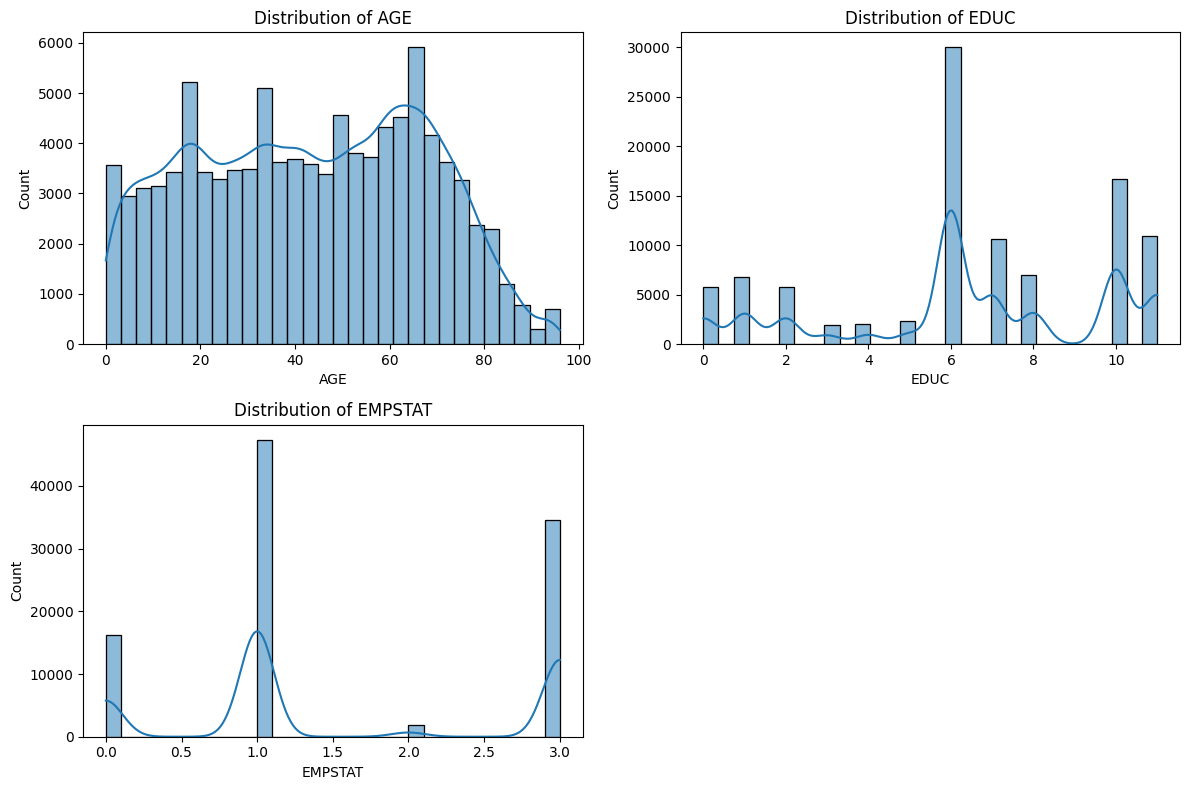

In [66]:
plt.figure(figsize=(12,8))

for i, col in enumerate(['AGE', 'EDUC', 'EMPSTAT']):
    plt.subplot(2,2,i+1)
    sns.histplot(df_sample[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

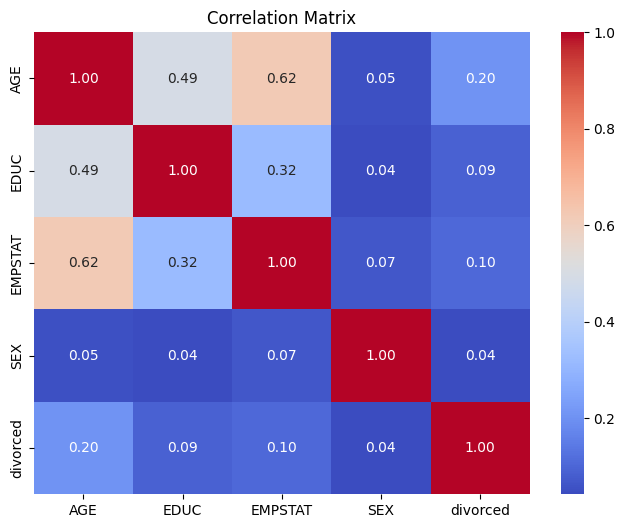

In [67]:
plt.figure(figsize=(8,6))

corr = df_sample[['AGE', 'EDUC', 'EMPSTAT', 'SEX', 'divorced']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

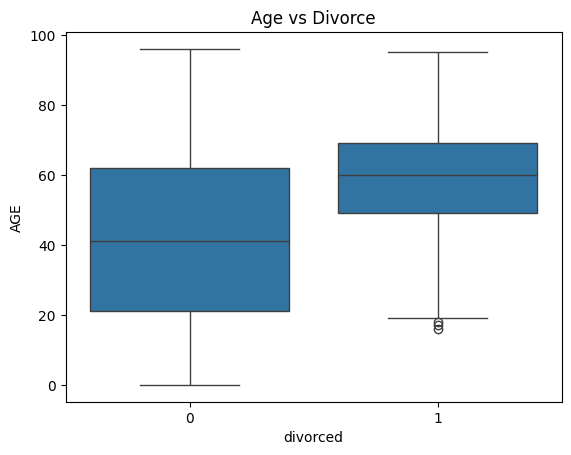

In [65]:
sns.boxplot(x='divorced', y='AGE', data=df_sample)
plt.title("Age vs Divorce")
plt.show()